In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("blackrock.csv")

In [3]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,17-07-2023,47387.11457,2980.571037,0.780701,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,13-01-2023,55806.54015,27996.690070,0.299268,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,28-09-2023,51080.47837,81482.156180,0.388445,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,05-02-2023,70472.70472,39598.371940,0.561809,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,19-11-2023,29830.48767,111731.993700,0.655635,391,20


In [4]:
df.shape

(800, 15)

In [5]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


## Task 1: Data Cleaning and Formatting

#### 1.1 Remove/treat any special characters or non-numeric entries from financial fields.

In [7]:
df[['TransactionAmount','AccountBalance','RiskScore','CreditRating']].dtypes

TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
dtype: object

In [8]:
df[['TransactionAmount','AccountBalance','RiskScore','CreditRating']].describe()

,TransactionAmount,AccountBalance,RiskScore,CreditRating
count,800.000000,800.000000,800.000000,800.000000
mean,54501.866711,72947.111696,0.466517,580.015000
std,29676.379125,34206.072059,0.233783,154.075237
min,-27916.911650,-35891.001750,-0.290309,306.000000
25%,34600.682150,51133.057895,0.312410,451.750000
50%,55524.078060,73006.751950,0.459326,575.000000
75%,73485.547887,94553.225110,0.630247,712.250000
max,165004.536900,171767.657800,1.200214,849.000000


In [9]:
# If special characters like $, ₹, commas would have appeared, we can clean them like this:

df['TransactionAmount'] = df['TransactionAmount'].replace('[^0-9.]','', regex=True)
df['AccountBalance'] = df['AccountBalance'].replace('[^0-9.]','', regex=True)

#### 1.2 Convert currency amounts into numerical format.

In [10]:
df['TransactionAmount'] = pd.to_numeric(df['TransactionAmount'])
df['AccountBalance'] = pd.to_numeric(df['AccountBalance'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


#### 1.3 Validate and format date columns. 

In [12]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True)

In [13]:
df['TransactionDate'].head()

0   2023-07-17
1   2023-01-13
2   2023-09-28
3   2023-02-05
4   2023-11-19
Name: TransactionDate, dtype: datetime64[ns]

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

#### 1.4 Ensure account types and transaction categories are standardized.

In [15]:
df['AccountType'] = df['AccountType'].str.strip().str.title()

In [16]:
df['TransactionType'] = df['TransactionType'].str.strip().str.title()

In [17]:
df[['AccountType', 'TransactionType']].head()

,AccountType,TransactionType
0,Credit,Withdrawal
1,Current,Payment
2,Current,Withdrawal
3,Loan,Deposit
4,Loan,Deposit


In [18]:
# pd.set_option('display.max_rows', 800)
# df

## Task 2: Descriptive Transactional Analysis

#### 2.1 Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [19]:
# Extracting Year and Month from the transaction date.

df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

In [20]:
# Separating Credit and Debit Transactions.

df['CreditAmount'] = df.apply(
    lambda x: x['TransactionAmount'] if x['TransactionType'] == 'Deposit' else 0, axis=1)

df['DebitAmount'] = df.apply(
    lambda x: x['TransactionAmount'] if x['TransactionType'] != 'Deposit' else 0, axis=1)

In [21]:
# Monthly Aggregation

monthly_summary = df.groupby(['Year','Month']).agg(
    Total_Credits = ('CreditAmount','sum'),
    Total_Debits = ('DebitAmount','sum')
).reset_index()

monthly_summary['Net_Transaction'] = (
    monthly_summary['Total_Credits'] - monthly_summary['Total_Debits']
)

In [22]:
# Yearly Aggregation

yearly_summary = df.groupby('Year').agg(
    Total_Credits = ('CreditAmount','sum'),
    Total_Debits = ('DebitAmount','sum')
).reset_index()

yearly_summary['Net_Transaction'] = (
    yearly_summary['Total_Credits'] - yearly_summary['Total_Debits']
)

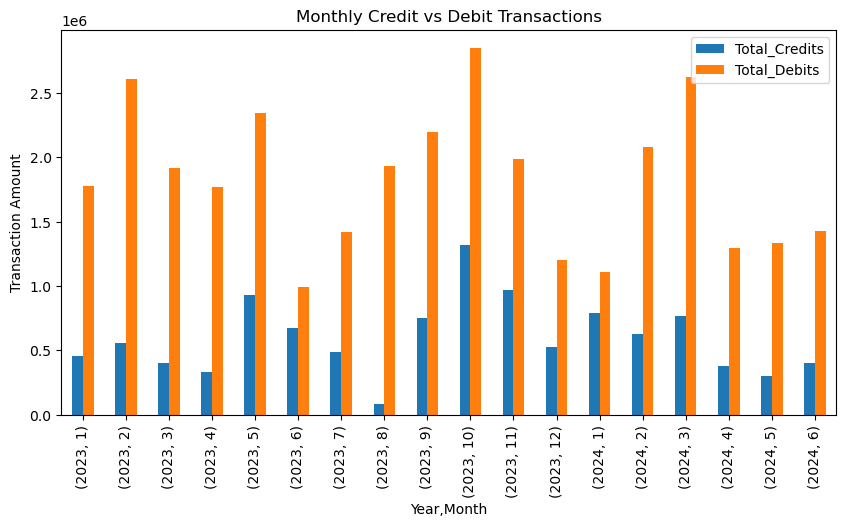

In [23]:
# Monthly Transaction Trend

import matplotlib.pyplot as plt

monthly_summary.set_index(['Year','Month'])[['Total_Credits','Total_Debits']].plot(kind='bar', figsize=(10,5))

plt.title('Monthly Credit vs Debit Transactions')
plt.ylabel('Transaction Amount')
plt.show()

#### 2.2 Plot trends in total credits vs. debits over time.

In [24]:
# Create a Proper Time Axis

monthly_summary['Date'] = pd.to_datetime(
    monthly_summary[['Year', 'Month']].assign(DAY=1)
)

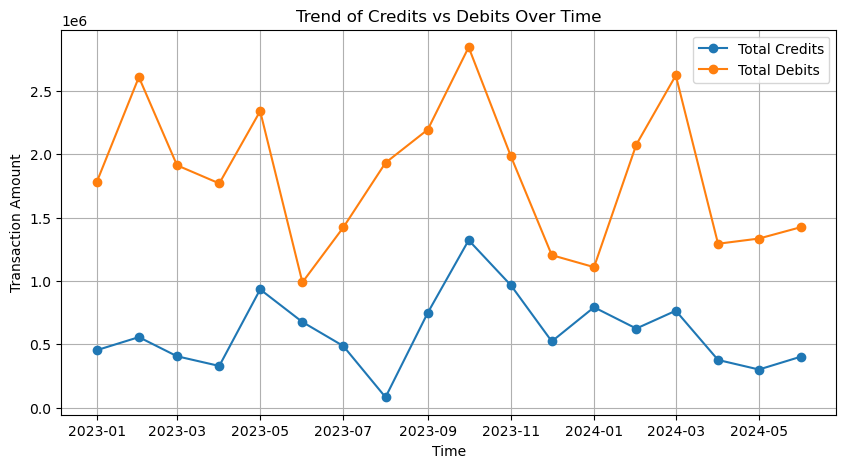

In [25]:
# Plot Credit vs Debit Trends

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_summary['Date'], monthly_summary['Total_Credits'], marker='o', label='Total Credits')
plt.plot(monthly_summary['Date'], monthly_summary['Total_Debits'], marker='o', label='Total Debits')

plt.title('Trend of Credits vs Debits Over Time')
plt.xlabel('Time')
plt.ylabel('Transaction Amount')

plt.legend()
plt.grid()

plt.show()

#### 2.3 Identify top and bottom performing accounts based on net inflow.

In [26]:
# Aggregate Data at Account Level

account_summary = df.groupby('AccountID').agg(
    Total_Credits = ('CreditAmount','sum'),
    Total_Debits = ('DebitAmount','sum')
).reset_index()

In [27]:
# Calculating Net Inflow

account_summary['Net_Inflow'] = (
    account_summary['Total_Credits'] - account_summary['Total_Debits']
)

In [28]:
# Identify Top Performing Accounts

top_accounts = account_summary.sort_values(by='Net_Inflow', ascending=False).head(10)
top_accounts

,AccountID,Total_Credits,Total_Debits,Net_Inflow
170,ACC88286,284230.60079,0.000000,284230.600790
24,ACC21719,281795.51780,7066.332080,274729.185720
102,ACC51200,251699.76008,50230.027640,201469.732440
43,ACC28295,262087.21231,62636.519390,199450.692920
163,ACC83269,180850.72689,0.000000,180850.726890
169,ACC88252,183519.24882,3893.024787,179626.224033
171,ACC88449,184286.91704,22156.027280,162130.889760
58,ACC32627,141764.34671,45164.130600,96600.216110
18,ACC18177,156307.38989,61506.258200,94801.131690
189,ACC99117,92159.60075,0.000000,92159.600750


In [29]:
# Identifying Bottom Performing Accounts

bottom_accounts = account_summary.sort_values(by='Net_Inflow', ascending=True).head(10)
bottom_accounts

,AccountID,Total_Credits,Total_Debits,Net_Inflow
83,ACC45101,35224.62786,475972.231650,-440747.603790
134,ACC70460,0.00000,432195.230130,-432195.230130
188,ACC97411,0.00000,416659.899393,-416659.899393
106,ACC52650,0.00000,387133.819950,-387133.819950
148,ACC77592,0.00000,383553.317399,-383553.317399
66,ACC35419,32955.23345,398856.436650,-365901.203200
153,ACC78581,0.00000,357789.158391,-357789.158391
184,ACC95774,0.00000,357669.637940,-357669.637940
138,ACC71938,0.00000,353666.209440,-353666.209440
157,ACC81631,0.00000,352890.598660,-352890.598660


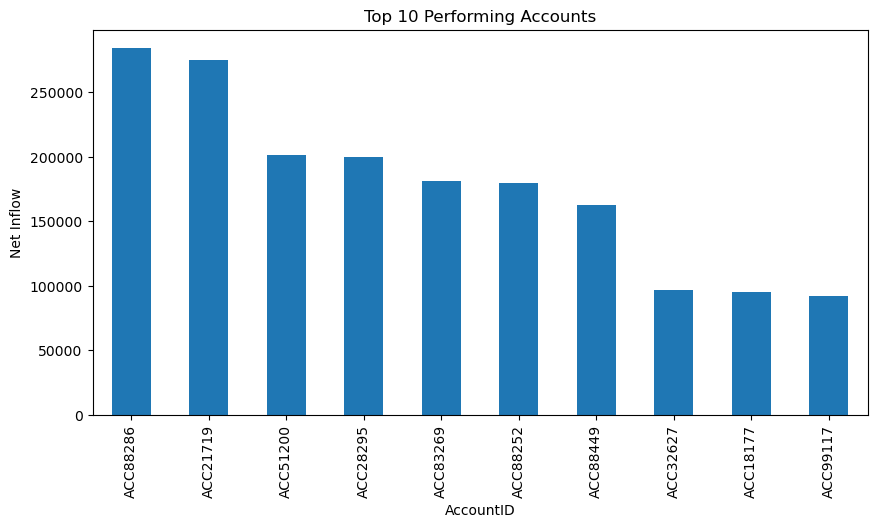

In [30]:
# Visualizing Top 10 Performing Accounts

top_accounts.set_index('AccountID')['Net_Inflow'].plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Performing Accounts')
plt.ylabel('Net Inflow')
plt.show()

#### 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [31]:
# Sorting Data Properly

df = df.sort_values(by=['AccountID', 'TransactionDate'])

In [32]:
# Calculating Previous Transaction Date

df['Prev_TransactionDate'] = df.groupby('AccountID')['TransactionDate'].shift(1)

In [33]:
# Calculating Gap (in Days)

df['Gap_Days'] = (df['TransactionDate'] - df['Prev_TransactionDate']).dt.days

In [34]:
# Flaging Dormant Transactions

df['Dormant_Flag'] = df['Gap_Days'].apply(lambda x: 1 if x >= 60 else 0)

In [35]:
# Identifying Dormant Accounts

dormant_accounts = df[df['Dormant_Flag'] == 1]['AccountID'].unique()
dormant_accounts

array(['ACC10117', 'ACC10996', 'ACC11062', 'ACC11188', 'ACC11285',
       'ACC11837', 'ACC12334', 'ACC13357', 'ACC15228', 'ACC15671',
       'ACC15925', 'ACC16241', 'ACC16664', 'ACC17688', 'ACC18057',
       'ACC18140', 'ACC18177', 'ACC19156', 'ACC19178', 'ACC20297',
       'ACC21264', 'ACC21429', 'ACC21719', 'ACC21878', 'ACC22036',
       'ACC22255', 'ACC22799', 'ACC23736', 'ACC23985', 'ACC24070',
       'ACC24508', 'ACC24880', 'ACC24981', 'ACC25811', 'ACC26026',
       'ACC26940', 'ACC26956', 'ACC26973', 'ACC28154', 'ACC28295',
       'ACC28305', 'ACC29007', 'ACC29231', 'ACC29356', 'ACC29646',
       'ACC30146', 'ACC30787', 'ACC30852', 'ACC32212', 'ACC32627',
       'ACC32890', 'ACC33287', 'ACC34119', 'ACC34431', 'ACC34568',
       'ACC34821', 'ACC35163', 'ACC35419', 'ACC37688', 'ACC38559',
       'ACC39161', 'ACC39482', 'ACC39500', 'ACC39529', 'ACC39544',
       'ACC40939', 'ACC41829', 'ACC42467', 'ACC42710', 'ACC42903',
       'ACC43309', 'ACC43771', 'ACC45101', 'ACC45521', 'ACC459

In [36]:
# Creating Account-Level Status

account_status = df.groupby('AccountID')['Dormant_Flag'].max().reset_index()

account_status['Account_Status'] = account_status['Dormant_Flag'].apply(
    lambda x: 'Dormant' if x == 1 else 'Active'
)

account_status

,AccountID,Dormant_Flag,Account_Status
0,ACC10117,1,Dormant
1,ACC10996,1,Dormant
2,ACC11062,1,Dormant
3,ACC11188,1,Dormant
4,ACC11285,1,Dormant
...,...,...,...
187,ACC97225,1,Dormant
188,ACC97411,1,Dormant
189,ACC99117,0,Active
190,ACC99409,1,Dormant


In [37]:
account_status['Account_Status'].value_counts()

Account_Status
Dormant    172
Active      20
Name: count, dtype: int64

In [38]:
account_status['Account_Status'].value_counts(normalize=True) * 100

Account_Status
Dormant    89.583333
Active     10.416667
Name: proportion, dtype: float64

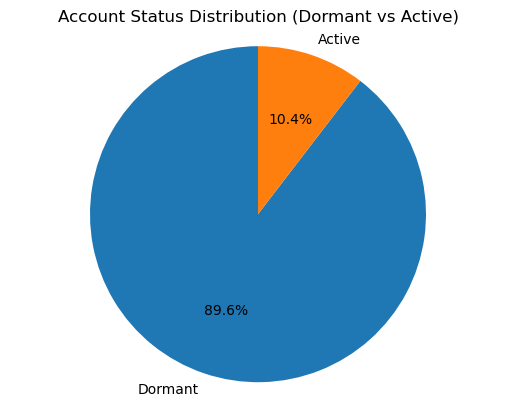

In [39]:
counts = account_status['Account_Status'].value_counts()

# Pie chart
plt.figure()
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=90)

plt.title('Account Status Distribution (Dormant vs Active)')
plt.axis('equal')  # Makes circle perfect

plt.show()

In [40]:
# If we want to see all rows of Account Status

# pd.set_option('display.max_rows', None)
# account_status

## Task 3: Customer Profile Building

#### 3.1 Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

##### Defining Rubric
##### High : ≥ 75th percentile    
##### Medium :  25th–75th percentile 
##### Low :  ≤ 25th percentile    

In [41]:
# Calculating Transaction Frequency

account_activity = df.groupby('AccountID').size().reset_index(name='Transaction_Count')

In [42]:
# Calculating Percentiles

q25 = account_activity['Transaction_Count'].quantile(0.25)
q75 = account_activity['Transaction_Count'].quantile(0.75)

In [43]:
# Assigning Activity Levels

def classify_activity(x):
    if x >= q75:
        return 'High'
    elif x <= q25:
        return 'Low'
    else:
        return 'Medium'

account_activity['Activity_Level'] = account_activity['Transaction_Count'].apply(classify_activity)

In [44]:
account_activity.head()

,AccountID,Transaction_Count,Activity_Level
0,ACC10117,6,High
1,ACC10996,4,Medium
2,ACC11062,6,High
3,ACC11188,9,High
4,ACC11285,5,High


In [45]:
account_activity['Activity_Level'].value_counts()

Activity_Level
Low       79
High      65
Medium    48
Name: count, dtype: int64

In [46]:
# pd.set_option('display.max_rows', None)
# account_activity

In [47]:
# To improve this segmentation
# We will use Ranking (Better Split)

account_activity['Rank'] = account_activity['Transaction_Count'].rank(pct=True)

def classify(x):
    if x >= 0.75:
        return 'High'
    elif x <= 0.25:
        return 'Low'
    else:
        return 'Medium'

account_activity['Activity_Level'] = account_activity['Rank'].apply(classify)

In [48]:
account_activity['Activity_Level'].value_counts()

Activity_Level
Medium    105
High       45
Low        42
Name: count, dtype: int64

In [49]:
account_activity.head()

,AccountID,Transaction_Count,Activity_Level,Rank
0,ACC10117,6,High,0.812500
1,ACC10996,4,Medium,0.539062
2,ACC11062,6,High,0.812500
3,ACC11188,9,High,0.984375
4,ACC11285,5,Medium,0.716146


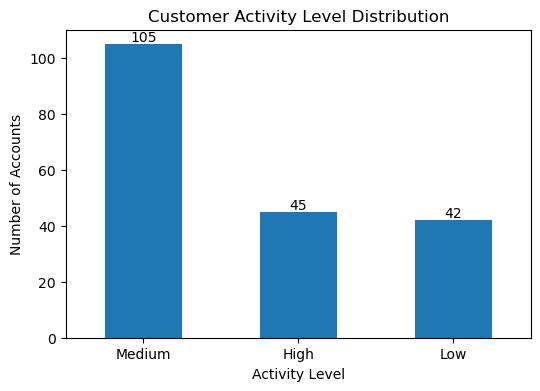

In [50]:
import matplotlib.pyplot as plt

ax=account_activity['Activity_Level'].value_counts().plot(kind='bar',figsize=(6,4))

ax.bar_label(ax.containers[0])

plt.title('Customer Activity Level Distribution')
plt.xlabel('Activity Level')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
plt.show()

In [51]:
# pd.set_option('display.max_rows', None)
# account_activity

#### 3.2 Segment customers by average balance and transaction volume. 

In [52]:
# Aggregating at Account Level

account_profile = df.groupby('AccountID').agg(
    Avg_Balance = ('AccountBalance','mean'),
    Total_Transaction = ('TransactionAmount','sum')
).reset_index()

In [53]:
# Calculating Percentiles

bal_q25 = account_profile['Avg_Balance'].quantile(0.25)
bal_q75 = account_profile['Avg_Balance'].quantile(0.75)

txn_q25 = account_profile['Total_Transaction'].quantile(0.25)
txn_q75 = account_profile['Total_Transaction'].quantile(0.75)

In [54]:
# Classify Balance

def balance_segment(x):
    if x >= bal_q75:
        return 'High Balance'
    elif x <= bal_q25:
        return 'Low Balance'
    else:
        return 'Medium Balance'

account_profile['Balance_Segment'] = account_profile['Avg_Balance'].apply(balance_segment)

In [55]:
# Classify Transaction Volume

def txn_segment(x):
    if x >= txn_q75:
        return 'High Volume'
    elif x <= txn_q25:
        return 'Low Volume'
    else:
        return 'Medium Volume'

account_profile['Transaction_Segment'] = account_profile['Total_Transaction'].apply(txn_segment)

In [56]:
# Combining Segments

account_profile['Customer_Segment'] = (
    account_profile['Balance_Segment'] + ' | ' + account_profile['Transaction_Segment']
)

In [57]:
account_profile.head()

,AccountID,Avg_Balance,Total_Transaction,Balance_Segment,Transaction_Segment,Customer_Segment
0,ACC10117,81106.206188,246887.286800,Medium Balance,Medium Volume,Medium Balance | Medium Volume
1,ACC10996,101733.898198,358817.022010,High Balance,High Volume,High Balance | High Volume
2,ACC11062,57108.763888,328776.968270,Low Balance,High Volume,Low Balance | High Volume
3,ACC11188,80235.151167,386419.024114,Medium Balance,High Volume,Medium Balance | High Volume
4,ACC11285,71205.645238,284440.530857,Medium Balance,Medium Volume,Medium Balance | Medium Volume


In [58]:
# Segmenting Distribution

account_profile['Customer_Segment'].value_counts()

Customer_Segment
Medium Balance | Medium Volume    49
Medium Balance | High Volume      25
Low Balance | Medium Volume       24
High Balance | Medium Volume      23
Medium Balance | Low Volume       22
High Balance | Low Volume         16
Low Balance | High Volume         14
Low Balance | Low Volume          10
High Balance | High Volume         9
Name: count, dtype: int64

In [59]:
pd.crosstab(account_profile['Balance_Segment'],
            account_profile['Transaction_Segment'])

Transaction_Segment,High Volume,Low Volume,Medium Volume
Balance_Segment,,,
High Balance,9,16,23
Low Balance,14,10,24
Medium Balance,25,22,49


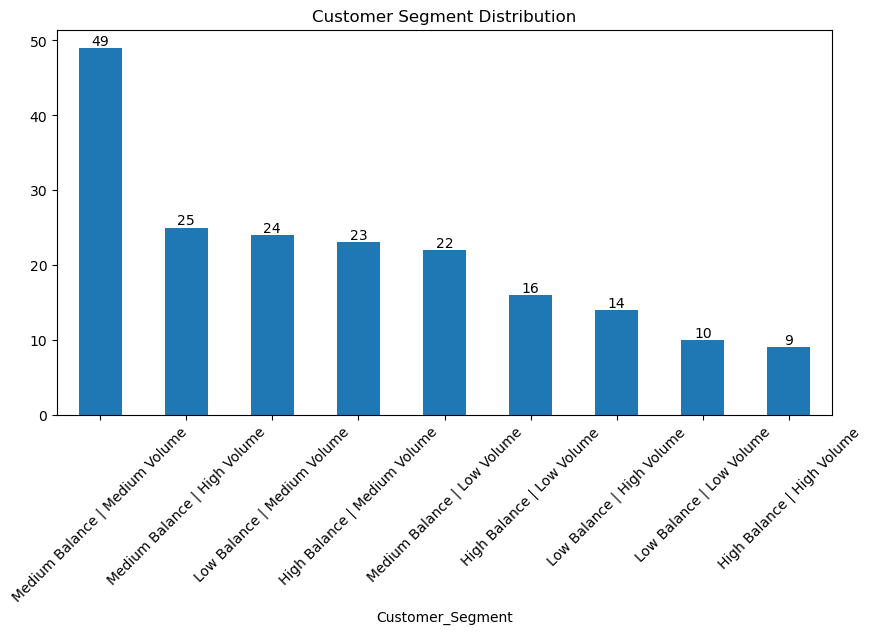

In [60]:
ax = account_profile['Customer_Segment'].value_counts().plot(kind='bar', figsize=(10,5))

# Adding data labels
ax.bar_label(ax.containers[0])

plt.xticks(rotation=45)
plt.title('Customer Segment Distribution')
plt.show()

#### 3.3 Create profiles for: 
#### High-net inflow accounts 
#### High-frequency low-balance accounts 
#### Accounts with negative or near-zero balances

##### 1. High-Net Inflow Accounts

In [61]:
# Using account_summary from Task 2.3

high_inflow_threshold = account_summary['Net_Inflow'].quantile(0.75)

high_net_inflow_accounts = account_summary[
    account_summary['Net_Inflow'] >= high_inflow_threshold
]

high_net_inflow_accounts.head()

,AccountID,Total_Credits,Total_Debits,Net_Inflow
6,ACC12182,130450.262350,49923.06381,80527.198540
9,ACC15228,46141.121310,51787.06991,-5645.948600
10,ACC15359,69405.131370,61378.50949,8026.621880
18,ACC18177,156307.389890,61506.25820,94801.131690
19,ACC19156,63106.086354,94881.99586,-31775.909506


##### 2. High-Frequency Low-Balance Accounts

In [62]:
# Merge activity + balance data

profile_df = account_profile.merge(account_activity, on='AccountID')

# Define thresholds
freq_threshold = profile_df['Transaction_Count'].quantile(0.75)
balance_threshold = profile_df['Avg_Balance'].quantile(0.25)

high_freq_low_balance = profile_df[
    (profile_df['Transaction_Count'] >= freq_threshold) &
    (profile_df['Avg_Balance'] <= balance_threshold)
]

high_freq_low_balance.head()

,AccountID,Avg_Balance,Total_Transaction,Balance_Segment,Transaction_Segment,Customer_Segment,Transaction_Count,Activity_Level,Rank
2,ACC11062,57108.763888,328776.96827,Low Balance,High Volume,Low Balance | High Volume,6,High,0.812500
31,ACC24070,53811.388618,338136.69381,Low Balance,High Volume,Low Balance | High Volume,5,Medium,0.716146
62,ACC34431,55556.756888,464671.95707,Low Balance,High Volume,Low Balance | High Volume,8,High,0.953125
66,ACC35419,53390.330235,431811.67010,Low Balance,High Volume,Low Balance | High Volume,6,High,0.812500
77,ACC41829,61628.656517,765315.96385,Low Balance,High Volume,Low Balance | High Volume,13,High,1.000000


##### 3. Negative or Near-Zero Balance Accounts

In [63]:
# Define near-zero threshold (example: < 1000)

negative_balance_accounts = account_profile[
    account_profile['Avg_Balance'] <= 1000
]

negative_balance_accounts.head()

,AccountID,Avg_Balance,Total_Transaction,Balance_Segment,Transaction_Segment,Customer_Segment


In [64]:
print("High Net Inflow:", len(high_net_inflow_accounts))
print("High Frequency Low Balance:", len(high_freq_low_balance))
print("Low / Negative Balance:", len(negative_balance_accounts))

High Net Inflow: 48
High Frequency Low Balance: 15
Low / Negative Balance: 0


In [65]:
common_accounts = set(high_freq_low_balance['AccountID']) & set(negative_balance_accounts['AccountID'])
len(common_accounts)

0

##### Since we did not get any meaningful insights from negative balance accounts, we will change the threshold from 1000 to 10th percentile. 

In [66]:
# Instead of fixed value (1000), we will use percentile-based threshold.

low_balance_threshold = account_profile['Avg_Balance'].quantile(0.10)

negative_balance_accounts = account_profile[
    account_profile['Avg_Balance'] <= low_balance_threshold]

In [67]:
print("High Net Inflow:", len(high_net_inflow_accounts))
print("High Frequency Low Balance:", len(high_freq_low_balance))
print("Low / Negative Balance:", len(negative_balance_accounts))

High Net Inflow: 48
High Frequency Low Balance: 15
Low / Negative Balance: 20


In [68]:
common_accounts = set(high_freq_low_balance['AccountID']) & set(negative_balance_accounts['AccountID'])
len(common_accounts)

2

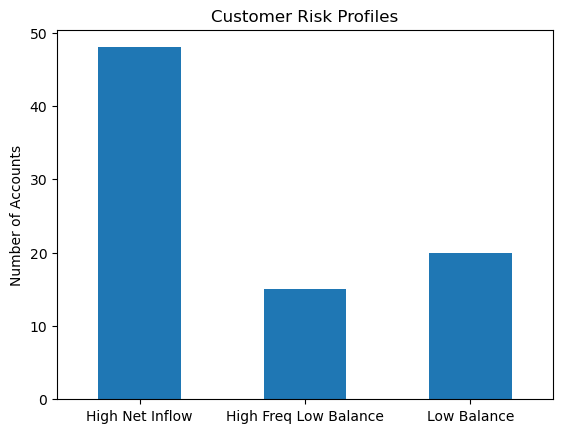

In [69]:
profile_counts = {
    'High Net Inflow': 48,
    'High Freq Low Balance': 15,
    'Low Balance': 20
}

pd.Series(profile_counts).plot(kind='bar')

plt.title('Customer Risk Profiles')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
plt.show()

## Task 4: Financial Risk Identification

#### 4.1 Track accounts with frequent large withdrawals or overdrafts.

In [70]:
# Filtering Withdrawal Transactions

withdrawals = df[df['TransactionType'] == 'Withdrawal']

In [71]:
# Defining Large Withdrawal Threshold

large_threshold = withdrawals['TransactionAmount'].quantile(0.90)

In [72]:
# Identifying Large Withdrawals

withdrawals['Large_Withdrawal'] = withdrawals['TransactionAmount'].apply(
    lambda x: 1 if x >= large_threshold else 0
)

C:\Users\RAM\AppData\Local\Temp\ipykernel_12984\3334604306.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  withdrawals['Large_Withdrawal'] = withdrawals['TransactionAmount'].apply(


In [73]:
# Count Large Withdrawals per Account

large_withdrawals_count = withdrawals.groupby('AccountID')['Large_Withdrawal'].sum().reset_index()

In [74]:
# Flag Frequent Large Withdrawals

freq_threshold = large_withdrawals_count['Large_Withdrawal'].quantile(0.90)

frequent_large_withdrawals = large_withdrawals_count[
    large_withdrawals_count['Large_Withdrawal'] >= freq_threshold
]

In [75]:
# Identifying Overdraft Accounts

overdraft_accounts = df[df['AccountBalance'] < 0]['AccountID'].unique()

In [76]:
# Combine Risky Accounts

risky_accounts = set(frequent_large_withdrawals['AccountID']) | set(overdraft_accounts)
len(risky_accounts)

35

In [77]:
print("Frequent Large Withdrawal Accounts:", len(frequent_large_withdrawals))
print("Overdraft Accounts:", len(overdraft_accounts))
print("Total Risky Accounts:", len(risky_accounts))

Frequent Large Withdrawal Accounts: 19
Overdraft Accounts: 17
Total Risky Accounts: 35


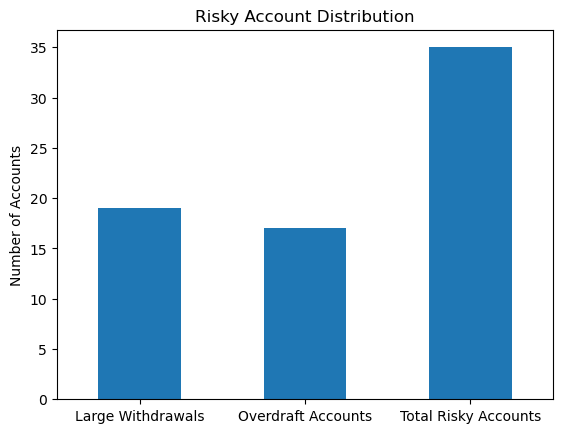

In [78]:
# Visualization

risk_counts = {
    'Large Withdrawals': 19,
    'Overdraft Accounts': 17,
    'Total Risky Accounts': 35
}

pd.Series(risk_counts).plot(kind='bar')

plt.title('Risky Account Distribution')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
plt.show()

#### 4.2 Calculate balance volatility using standard deviation or coefficient of variation.

In [79]:
# Calculating Balance Volatility per Account

balance_volatility = df.groupby('AccountID').agg(
    Avg_Balance = ('AccountBalance','mean'),
    Std_Balance = ('AccountBalance','std')
).reset_index()

In [80]:
# Calculating Coefficient of Variation (CV)

balance_volatility['CV'] = (
    balance_volatility['Std_Balance'] / balance_volatility['Avg_Balance']
)

In [81]:
# Handling Edge Cases

balance_volatility['CV'] = balance_volatility['CV'].replace([np.inf, -np.inf], 0)
balance_volatility['CV'] = balance_volatility['CV'].fillna(0)

In [82]:
# Identify High Volatility Accounts
# Using percentile threshold

vol_threshold = balance_volatility['CV'].quantile(0.75)

high_volatility_accounts = balance_volatility[
    balance_volatility['CV'] >= vol_threshold
]

In [83]:
high_volatility_accounts.head()

,AccountID,Avg_Balance,Std_Balance,CV
2,ACC11062,57108.763888,40017.803232,0.700730
11,ACC15671,27077.566847,30995.763211,1.144703
21,ACC20297,80846.693440,70164.033043,0.867865
24,ACC21719,72818.112908,49213.497040,0.675841
26,ACC22036,74872.558018,57748.822230,0.771295


In [84]:
print("High Volatility Accounts:", len(high_volatility_accounts))

High Volatility Accounts: 48


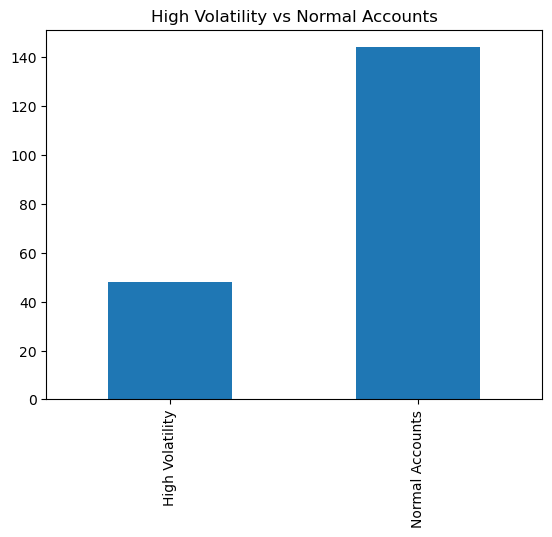

In [85]:
# Bar Chart

pd.Series({
    'High Volatility': 48,
    'Normal Accounts': 192-48
}).plot(kind='bar')

plt.title('High Volatility vs Normal Accounts')
plt.show()

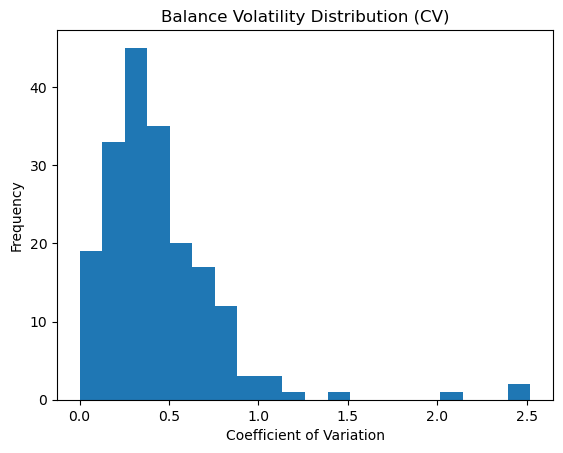

In [86]:
# Histogram
# Shows Distribution of volatility

balance_volatility['CV'].plot(kind='hist', bins=20)

plt.title('Balance Volatility Distribution (CV)')
plt.xlabel('Coefficient of Variation')
plt.show()

#### 4.3 Use IQR or z-score methods to detect anomalies. 

In [87]:
# Method 1: IQR (Interquartile Range)

Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies_iqr = df[
    (df['TransactionAmount'] < lower_bound) |
    (df['TransactionAmount'] > upper_bound)
]

len(anomalies_iqr)

7

In [88]:
# Method 2: Z-Score

from scipy.stats import zscore

df['Z_score'] = zscore(df['TransactionAmount'])

anomalies_z = df[
    (df['Z_score'] > 3) | (df['Z_score'] < -3)
]

len(anomalies_z)

4

In [89]:
print("IQR Anomalies:", len(anomalies_iqr))
print("Z-score Anomalies:", len(anomalies_z))

IQR Anomalies: 7
Z-score Anomalies: 4


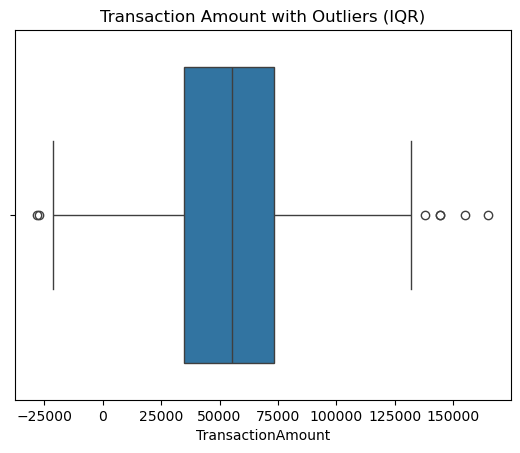

In [90]:
# Box Plot

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['TransactionAmount'])

plt.title('Transaction Amount with Outliers (IQR)')
plt.show()

#### 4.4 Highlight customers with irregular or suspicious transaction behaviour.

##### Converting All to Account Level

In [91]:
# Large Withdrawal Account

large_withdrawal_accounts = set(frequent_large_withdrawals['AccountID'])

In [92]:
# Overdraft Accounts

overdraft_accounts = set(df[df['AccountBalance'] < 0]['AccountID'])

In [93]:
# High Volatility Accounts

volatility_accounts = set(high_volatility_accounts['AccountID'])

In [94]:
# Anomaly Accounts

anomaly_accounts = set(anomalies_iqr['AccountID'])

In [95]:
# Creating Risk Score
# We assign a score based on how many risk factors an account has.

all_accounts = df['AccountID'].unique()

risk_df = pd.DataFrame({'AccountID': all_accounts})

risk_df['Large_Withdrawal_Flag'] = risk_df['AccountID'].isin(large_withdrawal_accounts).astype(int)
risk_df['Overdraft_Flag'] = risk_df['AccountID'].isin(overdraft_accounts).astype(int)
risk_df['Volatility_Flag'] = risk_df['AccountID'].isin(volatility_accounts).astype(int)
risk_df['Anomaly_Flag'] = risk_df['AccountID'].isin(anomaly_accounts).astype(int)

In [96]:
# Calculating Total Risk Score

risk_df['Risk_Score_Total'] = (
    risk_df['Large_Withdrawal_Flag'] +
    risk_df['Overdraft_Flag'] +
    risk_df['Volatility_Flag'] +
    risk_df['Anomaly_Flag']
)

In [97]:
# Identify Suspicious Customers

# Condition:At least 2 risk factors

suspicious_customers = risk_df[risk_df['Risk_Score_Total'] >= 2]
suspicious_customers.head()

,AccountID,Large_Withdrawal_Flag,Overdraft_Flag,Volatility_Flag,Anomaly_Flag,Risk_Score_Total
2,ACC11062,0,1,1,0,2
11,ACC15671,0,1,1,0,2
24,ACC21719,0,0,1,1,2
26,ACC22036,0,1,1,0,2
31,ACC24070,1,0,1,0,2


In [98]:
print("Suspicious Customers:", len(suspicious_customers))

Suspicious Customers: 26


In [99]:
# Risk Segmentation

def risk_level(x):
    if x >= 3:
        return 'High Risk'
    elif x == 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['Risk_Level'] = risk_df['Risk_Score_Total'].apply(risk_level)

In [100]:
risk_df['Risk_Level'].value_counts()

Risk_Level
Low Risk       166
Medium Risk     24
High Risk        2
Name: count, dtype: int64

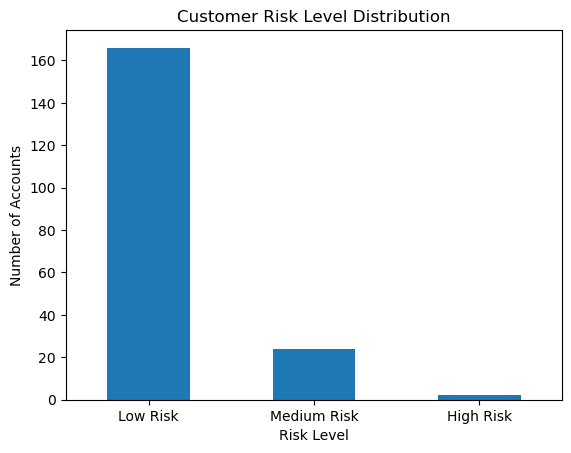

In [101]:
# Risk Level Distribution

risk_df['Risk_Level'].value_counts().plot(kind='bar')

plt.title('Customer Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=0)
plt.show()

## Task 5: Visualisation

#### Conduct extensive exploratory data analysis with attractive visualizations for your findings 

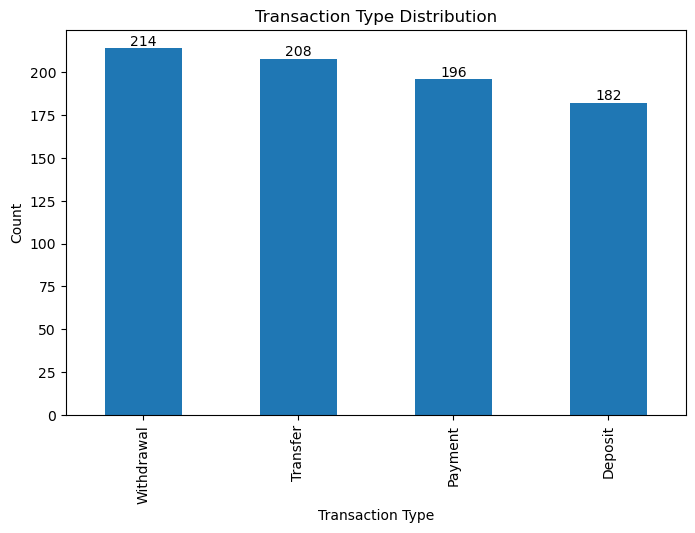

In [102]:
# 1. Transaction Type Distribution

ax = df['TransactionType'].value_counts().plot(kind='bar', figsize=(8,5))

ax.bar_label(ax.containers[0])

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

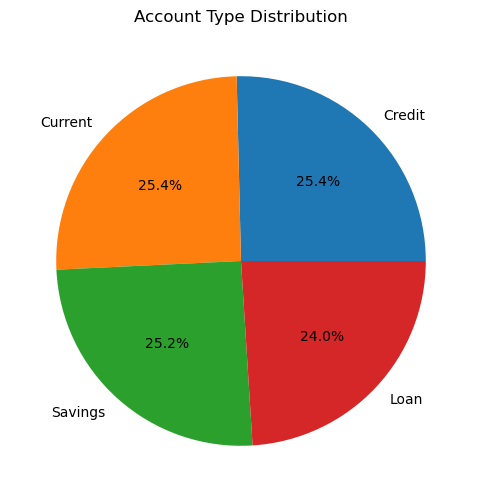

In [103]:
# 2. Account Type Distribution

df['AccountType'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title('Account Type Distribution')
plt.ylabel('')
plt.show()

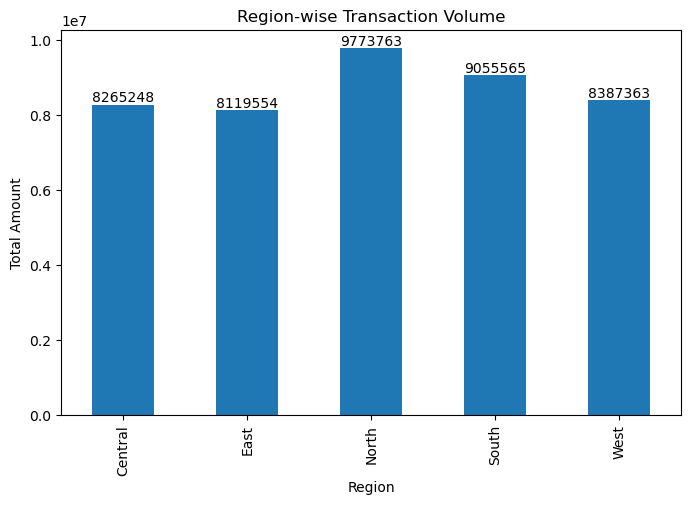

In [104]:
# 3. Region-wise Transactions

ax = df.groupby('Region')['TransactionAmount'].sum().plot(kind='bar', figsize=(8,5))

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title('Region-wise Transaction Volume')
plt.ylabel('Total Amount')
plt.show()

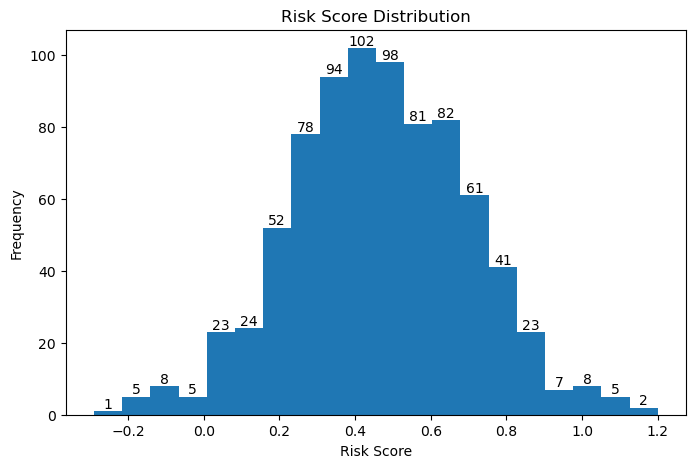

In [105]:
# 4. Risk Score Distribution

ax = df['RiskScore'].plot(kind='hist', bins=20, figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Risk Score Distribution')
plt.xlabel('Risk Score')
plt.show()

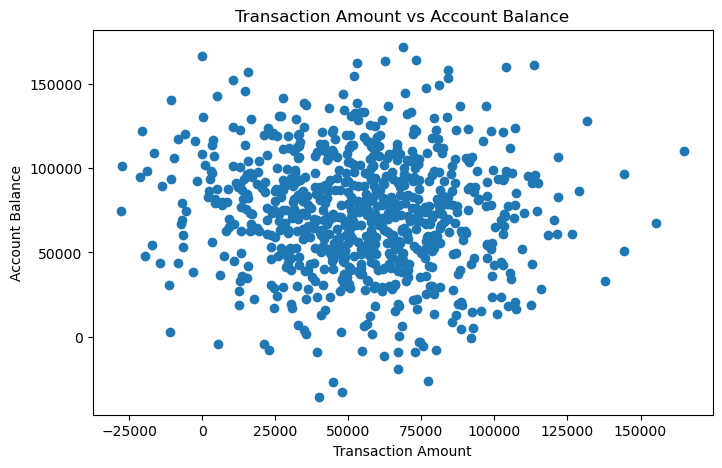

In [106]:
# 5. Balance vs Transaction Amount

plt.figure(figsize=(8,5))

plt.scatter(df['TransactionAmount'], df['AccountBalance'])

plt.title('Transaction Amount vs Account Balance')
plt.xlabel('Transaction Amount')
plt.ylabel('Account Balance')
plt.show()

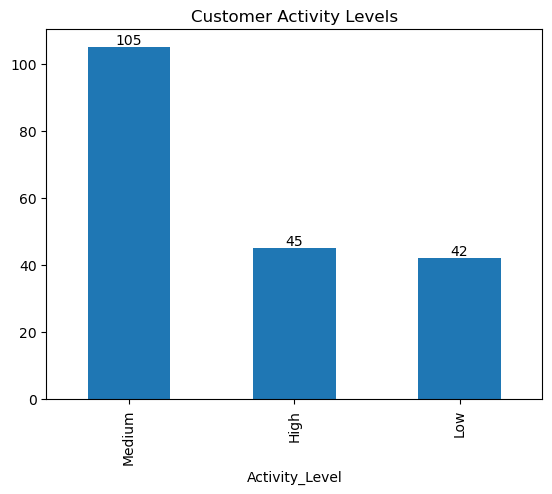

In [107]:
# 6. Activity Level Distribution

ax = account_activity['Activity_Level'].value_counts().plot(kind='bar')

ax.bar_label(ax.containers[0])

plt.title('Customer Activity Levels')
plt.show()

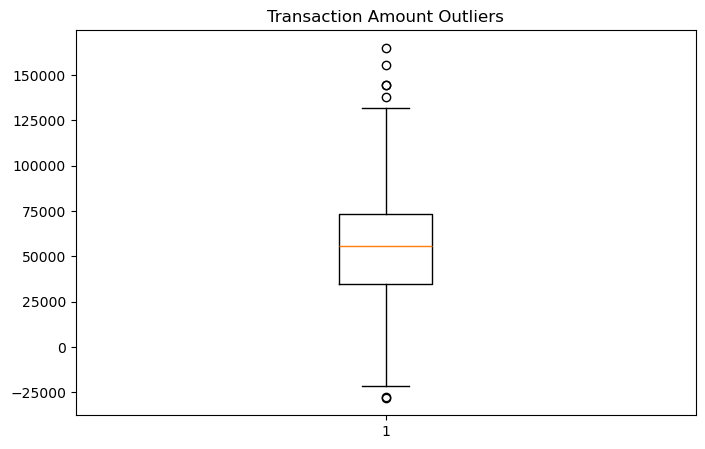

In [108]:
# 7. Boxplot for Outliers

plt.figure(figsize=(8,5))

plt.boxplot(df['TransactionAmount'])

plt.title('Transaction Amount Outliers')
plt.show()

<Axes: >

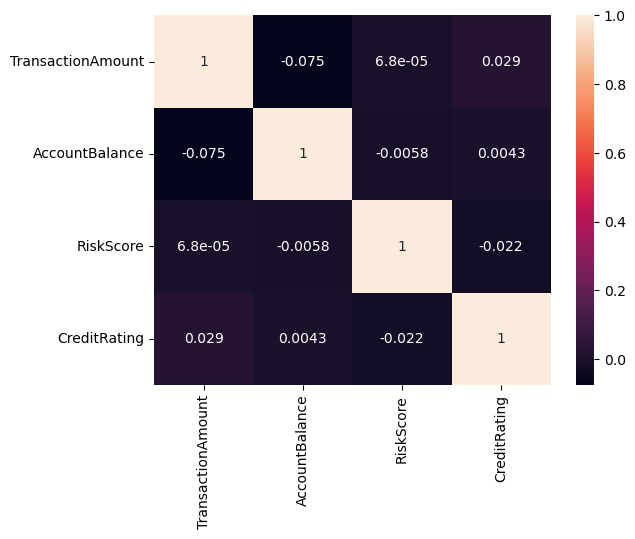

In [109]:
# 8. Heatmap

import seaborn as sns

corr = df[['TransactionAmount','AccountBalance','RiskScore','CreditRating']].corr()

sns.heatmap(corr, annot=True)

<Axes: xlabel='AccountType', ylabel='TransactionAmount'>

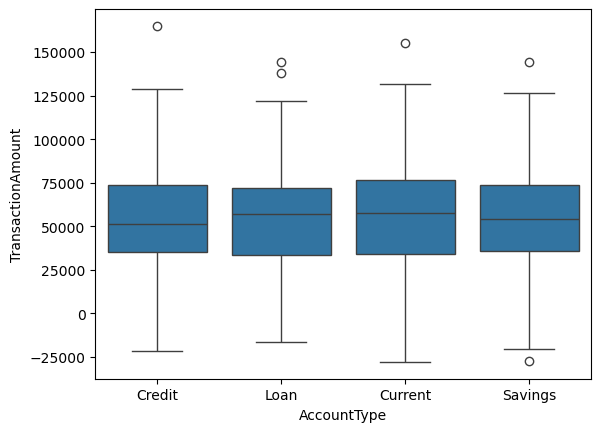

In [110]:
# 9. Boxplot by Account Type

sns.boxplot(x='AccountType', y='TransactionAmount', data=df)

## Task 6: Hypothesis Testing

#### 6.1 Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

#### Defining Hypotheses
##### Null Hypothesis (H₀) - There is NO difference in average balance between high-volume and low-volume accounts.
##### Alternative Hypothesis (H₁) - High-volume accounts have HIGHER average balance than low-volume accounts.

In [111]:
# Filtering High & Low Volume

high_volume = account_profile[
    account_profile['Transaction_Segment'] == 'High Volume'
]['Avg_Balance']

low_volume = account_profile[
    account_profile['Transaction_Segment'] == 'Low Volume'
]['Avg_Balance']

In [112]:
# Performing T-Test

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_volume, low_volume, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.909154168145703
P-value: 0.060066589508699246


In [113]:
# Comparing Means

print("High Volume Mean:", high_volume.mean())
print("Low Volume Mean:", low_volume.mean())

High Volume Mean: 72816.5224060049
Low Volume Mean: 82143.28675136805


<Axes: xlabel='Transaction_Segment', ylabel='Avg_Balance'>

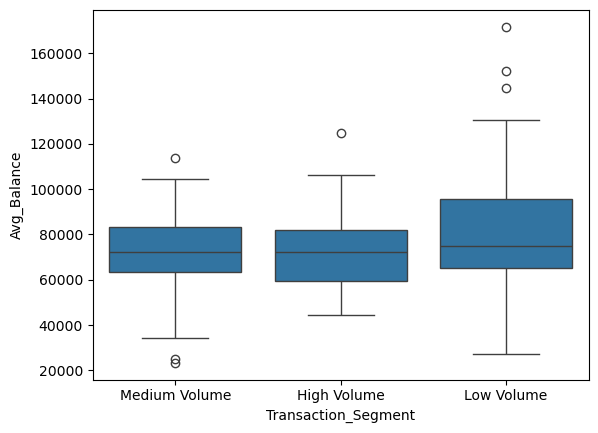

In [114]:
# Visualization 

sns.boxplot(x='Transaction_Segment', y='Avg_Balance', data=account_profile)

#### 6.2 Conduct hypothesis testing based on segmentation. 

#### ANOVA Test (Analysis of Variance)
#### Defining Hypotheses
##### Null Hypothesis (H₀) - There is no significant difference in average transaction amounts across different balance segments.
##### Alternative Hypothesis (H₁) - At least one segment has a different average transaction amount.

In [115]:
# Extracting Groups

high_bal = account_profile[
    account_profile['Balance_Segment'] == 'High Balance'
]['Total_Transaction']

medium_bal = account_profile[
    account_profile['Balance_Segment'] == 'Medium Balance'
]['Total_Transaction']

low_bal = account_profile[
    account_profile['Balance_Segment'] == 'Low Balance'
]['Total_Transaction']

In [116]:
# Performing ANOVA Test

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(high_bal, medium_bal, low_bal)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 3.7969377932681567
P-value: 0.024170018244767177


In [117]:
# Comparing Means

print("High Balance Mean:", high_bal.mean())
print("Medium Balance Mean:", medium_bal.mean())
print("Low Balance Mean:", low_bal.mean())

High Balance Mean: 185081.78531803898
Medium Balance Mean: 241929.24061964583
Low Balance Mean: 239424.1786288958


## Conclusion

### The analysis reveals that while most customers are financially stable, a small segment exhibits high-risk behavior driven by excessive withdrawals, overdrafts, and volatility. Transaction trends indicate higher outflows than inflows, and weak correlations suggest independent financial behaviors. These insights enable targeted risk management, improved customer engagement strategies, and data-driven decision-making.